
# TSP/Segment Routing for Plant Watering in Surabaya (OSRM)

**Goal:** start from one depot, visit every plant **segment** (each plant has a start point and an end point), choose the best traversal direction for each segment, and optionally return to the depot.

This notebook now uses **OSRM** instead of downloading the whole road graph from OSM. The workflow is:

1. Define 1 depot and plant segments (`start_lat`, `start_lon`, `end_lat`, `end_lon`)
2. Build an OSRM **table** between depot + all segment endpoints
3. Optimize the segment visit order
4. For a fixed order, choose the best direction of each segment with dynamic programming
5. Reconstruct the full driving route from OSRM **route** geometry
6. Visualize the result in **folium**


In [29]:
%pip install requests folium numpy matplotlib

In [30]:

import requests
import numpy as np
import folium
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from itertools import permutations

random.seed(42)
np.random.seed(42)

# Public demo server; for production use.
OSRM_BASE = "https://router.project-osrm.org"
PROFILE = "driving"

# If True, route becomes: DEPOT -> all segments -> DEPOT
# If False, route becomes: DEPOT -> all segments
RETURN_TO_DEPOT = True

from google.colab import files

uploaded = files.upload()


Saving parks.csv to parks (2).csv


## 1. Define depot and load plant segments from CSV

Each plant is a **segment**, not a single point, so the CSV should contain:

- `start_lat`, `start_lon`
- `end_lat`, `end_lon`

Optional columns:
- `park_id`
- `name`

If `name` is missing, the notebook will automatically use `park_id` or generate `Plant N`.


In [31]:
# Depot / start point
DEPOT = (-7.278358153631059, 112.76325243881848)

# CSV file path
CSV_PATH = "parks.csv"

# Required columns in the CSV
REQUIRED_COLUMNS = ["start_lat", "start_lon", "end_lat", "end_lon"]

df_segments = pd.read_csv(CSV_PATH)

missing_cols = [col for col in REQUIRED_COLUMNS if col not in df_segments.columns]
if missing_cols:
    raise ValueError(f"CSV is missing required columns: {missing_cols}")

def build_segment_name(row, idx):
    if "name" in row.index and pd.notna(row["name"]):
        return str(row["name"])
    if "park_id" in row.index and pd.notna(row["park_id"]):
        return f"Park {row['park_id']}"
    return f"Plant {idx + 1}"

PLANTS = []
for idx, row in df_segments.iterrows():
    PLANTS.append({
        "name": build_segment_name(row, idx),
        "start_lat": float(row["start_lat"]),
        "start_lon": float(row["start_lon"]),
        "end_lat": float(row["end_lat"]),
        "end_lon": float(row["end_lon"]),
    })

# print(f"Loaded {len(PLANTS)} segments from {CSV_PATH.name}")
display(df_segments.head())


,park_id,start_lat,start_lon,end_lat,end_lon
0,Jalan Kenjeran,-7.252887,112.795292,-7.249851,112.784502
1,Jalan Raya Mulyosari,-7.258301,112.795617,-7.273659,112.797714
2,Jalan Raya Kertajaya Indah,-7.279408,112.789619,-7.280560,112.781162
3,Jalan Raya Kertajaya Indah,-7.280611,112.780693,-7.279390,112.762482
4,Jalan Kertajaya,-7.279360,112.762112,-7.278325,112.756143



## 2. Prepare unique endpoints

We create one master list of coordinates:

- index 0 = depot
- every plant contributes:
  - `a_idx` = segment start endpoint
  - `b_idx` = segment end endpoint

OSRM's **table** service will give us pairwise road-network distances between all of these points.


In [32]:
POINTS = [DEPOT]
POINT_LABELS = ["Depot"]
SEGMENTS = []

for i, p in enumerate(PLANTS, start=1):
    a = (p["start_lat"], p["start_lon"])
    b = (p["end_lat"], p["end_lon"])

    a_idx = len(POINTS)
    POINTS.append(a)
    POINT_LABELS.append(f'{p["name"]} A')

    b_idx = len(POINTS)
    POINTS.append(b)
    POINT_LABELS.append(f'{p["name"]} B')

    SEGMENTS.append({
        "seg_id": i - 1,
        "name": p["name"],
        "a_idx": a_idx,
        "b_idx": b_idx,
    })

print("Total table points:", len(POINTS))
print("First 5 segments:")
for s in SEGMENTS[:5]:
    print(s)


Total table points: 69
First 5 segments:
{'seg_id': 0, 'name': 'Park Jalan Kenjeran', 'a_idx': 1, 'b_idx': 2}
{'seg_id': 1, 'name': 'Park Jalan Raya Mulyosari', 'a_idx': 3, 'b_idx': 4}
{'seg_id': 2, 'name': 'Park Jalan Raya Kertajaya Indah', 'a_idx': 5, 'b_idx': 6}
{'seg_id': 3, 'name': 'Park Jalan Raya Kertajaya Indah', 'a_idx': 7, 'b_idx': 8}
{'seg_id': 4, 'name': 'Park Jalan Kertajaya', 'a_idx': 9, 'b_idx': 10}


## Snap Coordinate

In [33]:
import time
import requests
import numpy as np

snap_cache = {}

def point_key(pt):
    return (round(pt[0], 6), round(pt[1], 6))

def osrm_nearest(pt, number=1, timeout=60):
    """
    Snap satu titik ke jaringan jalan OSRM memakai /nearest.
    pt = (lat, lon)
    return list kandidat snap
    """
    key = (point_key(pt), number)
    if key in snap_cache:
        return snap_cache[key]

    coord = f"{pt[1]:.6f},{pt[0]:.6f}"
    url = f"{OSRM_BASE}/nearest/v1/{PROFILE}/{coord}?number={number}"

    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()

    if data.get("code") != "Ok":
        raise RuntimeError(data)

    out = []
    for wp in data["waypoints"]:
        lon, lat = wp["location"]
        out.append({
            "input_latlon": pt,
            "snapped_latlon": (lat, lon),
            "distance_to_road_m": float(wp.get("distance", 0.0)),
            "name": wp.get("name", ""),
            "nodes": wp.get("nodes", []),
            "raw": wp,
        })

    snap_cache[key] = out
    return out

def snap_points(points, number=1, verbose=True, sleep_sec=0.05):
    """
    Snap semua titik.
    number=1  -> ambil 1 kandidat nearest
    number=2+ -> ambil beberapa kandidat nearest
    """
    snapped_points = []
    snap_infos = []

    for i, pt in enumerate(points):
        candidates = osrm_nearest(pt, number=number)
        chosen = candidates[0]   # sementara pilih kandidat terdekat
        snapped_points.append(chosen["snapped_latlon"])
        snap_infos.append({
            "index": i,
            "raw_latlon": pt,
            "snapped_latlon": chosen["snapped_latlon"],
            "distance_to_road_m": chosen["distance_to_road_m"],
            "road_name": chosen["name"],
            "all_candidates": candidates,
        })

        if verbose:
            print(
                f"[{i:>3}] raw={pt} -> snapped={chosen['snapped_latlon']} | "
                f"offset={chosen['distance_to_road_m']:.2f} m | road='{chosen['name']}'"
            )

        if sleep_sec > 0:
            time.sleep(sleep_sec)

    return snapped_points, snap_infos


SNAPPED_POINTS, SNAP_INFOS = snap_points(
    POINTS,
    number=1,      # bisa diganti 2 nanti kalau mau kandidat ganda
    verbose=True,
    sleep_sec=0.05
)

snap_df = pd.DataFrame([
    {
        "idx": info["index"],
        "label": POINT_LABELS[info["index"]],
        "raw_lat": info["raw_latlon"][0],
        "raw_lon": info["raw_latlon"][1],
        "snap_lat": info["snapped_latlon"][0],
        "snap_lon": info["snapped_latlon"][1],
        "offset_m": info["distance_to_road_m"],
        "road_name": info["road_name"],
    }
    for info in SNAP_INFOS
])

display(snap_df.head(20))
print("Max snap offset (m):", snap_df["offset_m"].max())
print("Mean snap offset (m):", snap_df["offset_m"].mean())

[  0] raw=(-7.278358153631059, 112.76325243881848) -> snapped=(-7.277913, 112.763309) | offset=49.61 m | road='Jalan Sukodami III'
[  1] raw=(-7.252886945178494, 112.79529218895492) -> snapped=(-7.252987, 112.795263) | offset=11.51 m | road='Jalan Kenjeran'
[  2] raw=(-7.249851160739066, 112.7845023166069) -> snapped=(-7.249759, 112.784534) | offset=10.77 m | road='Jalan Kenjeran'
[  3] raw=(-7.258301153658709, 112.79561663072866) -> snapped=(-7.258302, 112.795631) | offset=1.55 m | road='Jalan Raya Mulyosari'
[  4] raw=(-7.2736585383304995, 112.79771417459334) -> snapped=(-7.273665, 112.797696) | offset=2.10 m | road='Jalan Raya Mulyosari'
[  5] raw=(-7.27940813067957, 112.78961915600104) -> snapped=(-7.27941, 112.789669) | offset=5.53 m | road=''
[  6] raw=(-7.28056016219701, 112.7811623896963) -> snapped=(-7.280487, 112.781151) | offset=8.16 m | road='Jalan Raya Kertajaya Indah'
[  7] raw=(-7.280610704725042, 112.78069309453196) -> snapped=(-7.280703, 112.780692) | offset=10.18 m | 

,idx,label,raw_lat,raw_lon,snap_lat,snap_lon,offset_m,road_name
0,0,Depot,-7.278358,112.763252,-7.277913,112.763309,49.614380,Jalan Sukodami III
1,1,Park Jalan Kenjeran A,-7.252887,112.795292,-7.252987,112.795263,11.513547,Jalan Kenjeran
2,2,Park Jalan Kenjeran B,-7.249851,112.784502,-7.249759,112.784534,10.770769,Jalan Kenjeran
3,3,Park Jalan Raya Mulyosari A,-7.258301,112.795617,-7.258302,112.795631,1.549960,Jalan Raya Mulyosari
4,4,Park Jalan Raya Mulyosari B,-7.273659,112.797714,-7.273665,112.797696,2.095557,Jalan Raya Mulyosari
5,5,Park Jalan Raya Kertajaya Indah A,-7.279408,112.789619,-7.279410,112.789669,5.525892,
6,6,Park Jalan Raya Kertajaya Indah B,-7.280560,112.781162,-7.280487,112.781151,8.164096,Jalan Raya Kertajaya Indah
7,7,Park Jalan Raya Kertajaya Indah A,-7.280611,112.780693,-7.280703,112.780692,10.175071,Jalan Raya Kertajaya Indah
8,8,Park Jalan Raya Kertajaya Indah B,-7.279390,112.762482,-7.279318,112.762494,8.072144,Jalan Manyar Kertoarjo
9,9,Park Jalan Kertajaya A,-7.279360,112.762112,-7.279432,112.762099,8.091005,Jalan Kertajaya


Max snap offset (m): 49.61437951
Mean snap offset (m): 6.107475213271013



## 3. Query OSRM table (road distances in meters)

`dist_matrix[i, j]` = driving distance from point `i` to point `j`.

OSRM may be asymmetric because of one-way roads.


In [34]:
import math
import time
import requests
import numpy as np

def ll_to_osrm(pt):
    # OSRM expects lon,lat
    lat, lon = pt
    return f"{lon:.6f},{lat:.6f}"

def chunk_indices(n, batch_size):
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        yield list(range(start, end))

def build_table_url(points, annotations="distance", sources=None, destinations=None):
    coords = ";".join(ll_to_osrm(p) for p in points)
    url = f"{OSRM_BASE}/table/v1/{PROFILE}/{coords}?annotations={annotations}"

    if sources is not None:
        url += "&sources=" + ";".join(str(i) for i in sources)
    if destinations is not None:
        url += "&destinations=" + ";".join(str(i) for i in destinations)

    return url

def osrm_table_submatrix(points, source_idx, dest_idx, timeout=120, sleep_sec=0.0):
    """
    Request submatrix:
    rows    = source_idx
    columns = dest_idx
    """
    url = build_table_url(
        points,
        annotations="distance",
        sources=source_idx,
        destinations=dest_idx,
    )

    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()

    if data.get("code") != "Ok":
        raise RuntimeError(data)

    distances = data.get("distances")
    if distances is None:
        raise RuntimeError("OSRM table response does not contain distances.")

    D = np.array(
        [[np.inf if v is None else float(v) for v in row] for row in distances],
        dtype=float
    )

    if sleep_sec > 0:
        time.sleep(sleep_sec)

    return D, data

def osrm_table_batched(points, batch_size=25, timeout=120, sleep_sec=0.0, verbose=True):
    """
    Build full NxN distance matrix by requesting OSRM /table in batches.
    """
    n = len(points)
    full = np.full((n, n), np.inf, dtype=float)

    row_batches = list(chunk_indices(n, batch_size))
    col_batches = list(chunk_indices(n, batch_size))

    total_requests = len(row_batches) * len(col_batches)
    req_no = 0

    for rows in row_batches:
        for cols in col_batches:
            req_no += 1
            if verbose:
                print(
                    f"Request {req_no}/{total_requests} | "
                    f"rows {rows[0]}-{rows[-1]} | cols {cols[0]}-{cols[-1]}"
                )

            subD, _ = osrm_table_submatrix(
                points,
                source_idx=rows,
                dest_idx=cols,
                timeout=timeout,
                sleep_sec=sleep_sec,
            )

            full[np.ix_(rows, cols)] = subD

    return full

dist_matrix = osrm_table_batched(
    SNAPPED_POINTS,
    batch_size=25,
    timeout=120,
    sleep_sec=0.1,
    verbose=True
)

print("Distance matrix shape:", dist_matrix.shape)
print(np.round(dist_matrix, 0))

Request 1/9 | rows 0-24 | cols 0-24
Request 2/9 | rows 0-24 | cols 25-49
Request 3/9 | rows 0-24 | cols 50-68
Request 4/9 | rows 25-49 | cols 0-24
Request 5/9 | rows 25-49 | cols 25-49
Request 6/9 | rows 25-49 | cols 50-68
Request 7/9 | rows 50-68 | cols 0-24
Request 8/9 | rows 50-68 | cols 25-49
Request 9/9 | rows 50-68 | cols 50-68
Distance matrix shape: (69, 69)
[[   0. 6952. 5805. ... 4668. 5448. 4715.]
 [7135.    0. 1321. ... 7571. 8792. 9365.]
 [6087. 1288.    0. ... 6524. 7744. 8317.]
 ...
 [4726. 7030. 5883. ...    0. 1870. 2443.]
 [5652. 8152. 7006. ... 1247.    0. 1300.]
 [4352. 9387. 8240. ... 2482. 1234.    0.]]



## 4. Cost of a fixed segment order

For each segment there are 2 traversal directions:

- orientation `0`: A → B
- orientation `1`: B → A

For a fixed order of segments, we use dynamic programming to choose the best orientation sequence.


In [35]:

DEPOT_IDX = 0

def evaluate_order(order, D, segments, return_to_depot=True):
    '''
    order: list of segment indices, e.g. [3, 0, 2, 1]
    returns:
      total_cost_m,
      orientations (0 = A->B, 1 = B->A),
      dp_table
    '''
    if len(order) == 0:
        return 0.0, [], []

    first = segments[order[0]]
    a0, b0 = first["a_idx"], first["b_idx"]

    # dp[k][ori] = minimum cost after finishing segment k with orientation ori
    dp = []
    parent = []

    first_costs = [0.0, 0.0]
    # ori 0: Depot -> A -> B
    first_costs[0] = D[DEPOT_IDX, a0] + D[a0, b0]
    # ori 1: Depot -> B -> A
    first_costs[1] = D[DEPOT_IDX, b0] + D[b0, a0]

    dp.append(first_costs)
    parent.append([-1, -1])

    for pos in range(1, len(order)):
        prev_seg = segments[order[pos - 1]]
        curr_seg = segments[order[pos]]

        prev_exit = [
            prev_seg["b_idx"],  # if prev ori=0, exits at B
            prev_seg["a_idx"],  # if prev ori=1, exits at A
        ]

        curr_entry = [
            curr_seg["a_idx"],  # if curr ori=0, enters at A
            curr_seg["b_idx"],  # if curr ori=1, enters at B
        ]
        curr_exit = [
            curr_seg["b_idx"],  # if curr ori=0, exits at B
            curr_seg["a_idx"],  # if curr ori=1, exits at A
        ]

        leg_inside = [
            D[curr_seg["a_idx"], curr_seg["b_idx"]],  # A->B
            D[curr_seg["b_idx"], curr_seg["a_idx"]],  # B->A
        ]

        curr_dp = [np.inf, np.inf]
        curr_parent = [-1, -1]

        for curr_ori in [0, 1]:
            best_val = np.inf
            best_prev_ori = -1

            for prev_ori in [0, 1]:
                candidate = (
                    dp[pos - 1][prev_ori]
                    + D[prev_exit[prev_ori], curr_entry[curr_ori]]
                    + leg_inside[curr_ori]
                )
                if candidate < best_val:
                    best_val = candidate
                    best_prev_ori = prev_ori

            curr_dp[curr_ori] = best_val
            curr_parent[curr_ori] = best_prev_ori

        dp.append(curr_dp)
        parent.append(curr_parent)

    # Finish: maybe return to depot
    last_seg = segments[order[-1]]
    last_exit = [last_seg["b_idx"], last_seg["a_idx"]]

    final_costs = dp[-1][:]
    if return_to_depot:
        final_costs = [
            dp[-1][0] + D[last_exit[0], DEPOT_IDX],
            dp[-1][1] + D[last_exit[1], DEPOT_IDX],
        ]

    best_last_ori = int(np.argmin(final_costs))
    best_cost = float(final_costs[best_last_ori])

    # Backtrack orientations
    orientations = [None] * len(order)
    orientations[-1] = best_last_ori
    for pos in range(len(order) - 1, 0, -1):
        orientations[pos - 1] = parent[pos][orientations[pos]]

    return best_cost, orientations, dp

# quick sanity check
sample_order = list(range(len(SEGMENTS)))
sample_cost, sample_oris, _ = evaluate_order(sample_order, dist_matrix, SEGMENTS, RETURN_TO_DEPOT)
print("Sample order:", sample_order)
print("Sample orientations:", sample_oris)
print(f"Sample total cost = {sample_cost:,.0f} m")


Sample order: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Sample orientations: [1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
Sample total cost = 106,766 m


## 5. Optimise segment order

The segment visit order is optimised using a **pure Genetic Algorithm (GA)**.  
This approach is used because the number of possible segment permutations grows
very quickly as the number of segments increases, making brute-force search
impractical for real cases.

### Why Genetic Algorithm is used

Each candidate solution represents an ordering of road segments to be visited.  
The objective is to find the order that minimises the total travel distance.  
Instead of testing all possible permutations, the GA searches iteratively by
maintaining a population of candidate orders and improving them over multiple
generations.

### What this implementation does

This implementation uses a **pure permutation-based GA** with the following components:

- **Initial population**  
  A random population of segment orders is generated at the beginning.

- **Tournament selection**  
  Parents are selected by randomly sampling several individuals and choosing the
  one with the lowest route cost. This biases reproduction toward better solutions
  while still preserving some diversity.

- **Order crossover (OX)**  
  A subsequence from one parent is copied into the child, and the remaining
  positions are filled using the order of segments from the other parent without
  duplication. This ensures that the child remains a valid permutation.

- **Swap mutation**  
  With a small probability, two positions in a route are swapped. This introduces
  variation and helps prevent the population from becoming too uniform too early.

- **Fitness evaluation**  
  Each segment order is evaluated using `evaluate_order`, which computes the total
  travel distance. At the same time, the function determines the best orientation
  for every segment (A→B or B→A).

### Search process

The optimisation proceeds as follows:

1. Generate an initial population of random segment orders  
2. Compute the route cost of every individual  
3. Select parent solutions using tournament selection  
4. Produce offspring using order crossover and swap mutation  
5. Replace the current population with the offspring  
6. Repeat for a fixed number of generations  

The best solution found during all generations is stored as the final result.

### Recorded convergence information

During the run, three statistics are stored:

- **Best in population** → best route in the current generation  
- **Best so far** → best route found since the start  
- **Average fitness** → average route cost of the population  

These metrics can be used to visualise convergence behaviour.

### Limitation of this approach

Because this implementation uses **GA only**, the result is an approximate
solution and is not guaranteed to be globally optimal. The solution quality depends
on parameters such as population size, mutation rate, crossover rate, and number
of generations.

Without additional local search operators (e.g., 2-opt or Or-opt), the algorithm
may converge to a suboptimal route, although it generally performs well for
medium-sized instances.

In [36]:
import random
import numpy as np
from itertools import permutations
from functools import lru_cache

# ── Cached cost helper ────────────────────────────────────────────────────────
def make_cost_fn(D, segments, return_to_depot=True):
    @lru_cache(maxsize=200000)
    def cached_cost(order_tuple):
        cost, _, _ = evaluate_order(order_tuple, D, segments, return_to_depot)
        return float(cost)
    return cached_cost


# ── GA helpers ────────────────────────────────────────────────────────────────
def init_population(pop_size, n_segments):
    base = list(range(n_segments))
    return [random.sample(base, len(base)) for _ in range(pop_size)]


def tournament(pop, fits, k=3):
    picks = random.sample(range(len(pop)), k)
    best  = min(picks, key=lambda i: fits[i])
    return pop[best][:]


def ox_crossover(p1, p2):
    size = len(p1)
    a, b = sorted(random.sample(range(size), 2))
    child = [None] * size
    child[a:b+1] = p1[a:b+1]

    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(size):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1

    return child


def swap_mutation(perm, rate=0.04):
    perm = perm[:]
    for i in range(len(perm)):
        if random.random() < rate:
            j = random.randrange(len(perm))
            perm[i], perm[j] = perm[j], perm[i]
    return perm


# ── Genetic Algorithm ────────────────────────────────────────────────────
def genetic_algorithm_pure(
    D, segments,
    pop_size=80,
    generations=180,
    mut_rate=0.04,
    crossover_rate=0.9,
    tournament_k=3,
    return_to_depot=True,
):
    n = len(segments)
    cost_fn = make_cost_fn(D, segments, return_to_depot)

    pop = init_population(pop_size, n)

    best_order = None
    best_cost = np.inf

    best_in_population_history = []
    best_so_far_history = []
    avg_fitness_history = []

    for gen in range(generations):
        fits = [cost_fn(tuple(ind)) for ind in pop]

        gen_best_idx = int(np.argmin(fits))
        gen_best_cost = fits[gen_best_idx]
        gen_best_order = pop[gen_best_idx][:]

        if gen_best_cost < best_cost:
            best_cost = gen_best_cost
            best_order = gen_best_order[:]

        best_in_population_history.append(gen_best_cost)
        best_so_far_history.append(best_cost)
        avg_fitness_history.append(float(np.mean(fits)))

        new_pop = []

        while len(new_pop) < pop_size:
            p1 = tournament(pop, fits, k=tournament_k)
            p2 = tournament(pop, fits, k=tournament_k)

            if random.random() < crossover_rate:
                child1 = ox_crossover(p1, p2)
                child2 = ox_crossover(p2, p1)
            else:
                child1 = p1[:]
                child2 = p2[:]

            child1 = swap_mutation(child1, rate=mut_rate)
            child2 = swap_mutation(child2, rate=mut_rate)

            new_pop.append(child1)
            if len(new_pop) < pop_size:
                new_pop.append(child2)

        pop = new_pop

        if gen % 20 == 0:
            print(
                f"Gen {gen:4d} | "
                f"best_pop = {gen_best_cost:,.0f} m | "
                f"best_so_far = {best_cost:,.0f} m | "
                f"avg = {np.mean(fits):,.0f} m"
            )

    final_cost, final_oris, _ = evaluate_order(best_order, D, segments, return_to_depot)

    history = {
        "best_in_population": best_in_population_history,
        "best_so_far": best_so_far_history,
        "avg_fitness": avg_fitness_history,
    }

    return best_order, final_oris, float(final_cost), history


# ── Run optimisation ──────────────────────────────────────────────────────────
print("Using GENETIC ALGORITHM...")
best_order, best_orientations, best_len, hist = genetic_algorithm_pure(
    dist_matrix,
    SEGMENTS,
    pop_size=80,
    generations=180,
    mut_rate=0.04,
    crossover_rate=0.9,
    tournament_k=3,
    return_to_depot=RETURN_TO_DEPOT,
)


print("\nBest segment order :", best_order)
print("Best orientations  :", best_orientations, "(0=A->B, 1=B->A)")
print(f"Total distance     : {best_len:,.0f} m ({best_len/1000:.2f} km)")

Using GENETIC ALGORITHM...
Gen    0 | best_pop = 122,130 m | best_so_far = 122,130 m | avg = 158,549 m
Gen   20 | best_pop = 111,989 m | best_so_far = 111,989 m | avg = 136,289 m
Gen   40 | best_pop = 113,059 m | best_so_far = 108,589 m | avg = 133,603 m
Gen   60 | best_pop = 109,025 m | best_so_far = 106,041 m | avg = 133,876 m
Gen   80 | best_pop = 111,795 m | best_so_far = 103,972 m | avg = 128,058 m
Gen  100 | best_pop = 109,959 m | best_so_far = 96,243 m | avg = 134,706 m
Gen  120 | best_pop = 115,313 m | best_so_far = 96,243 m | avg = 134,455 m
Gen  140 | best_pop = 115,097 m | best_so_far = 96,243 m | avg = 132,366 m
Gen  160 | best_pop = 109,879 m | best_so_far = 96,243 m | avg = 135,860 m

Best segment order : [31, 30, 32, 33, 12, 14, 13, 11, 29, 28, 21, 15, 5, 19, 22, 18, 27, 7, 6, 9, 8, 2, 1, 0, 23, 16, 20, 10, 17, 26, 24, 25, 3, 4]
Best orientations  : [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0] (0=A->B, 1=B->A)
Tot

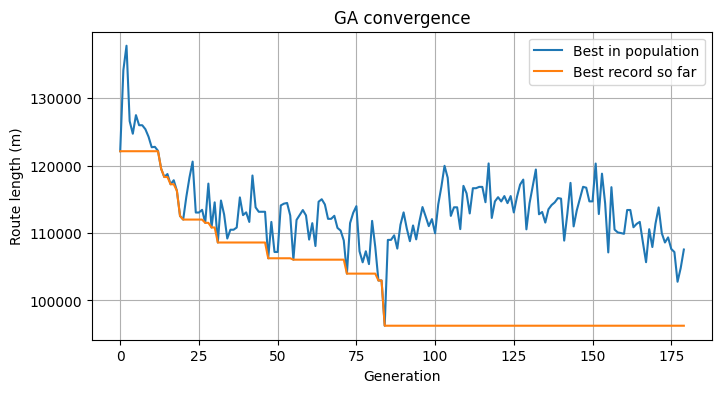

In [37]:
if hist is not None:
    plt.figure(figsize=(8, 4))
    plt.plot(hist["best_in_population"], label="Best in population")
    plt.plot(hist["best_so_far"], label="Best record so far")
    plt.xlabel("Generation")
    plt.ylabel("Route length (m)")
    plt.title("GA convergence")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("Exact mode used, so there is no GA convergence plot.")


## 6. Inspect chosen traversal directions


In [38]:

def segment_orientation_summary(order, orientations, segments):
    rows = []
    for step, (seg_idx, ori) in enumerate(zip(order, orientations), start=1):
        seg = segments[seg_idx]
        direction = "A -> B" if ori == 0 else "B -> A"
        entry_idx = seg["a_idx"] if ori == 0 else seg["b_idx"]
        exit_idx = seg["b_idx"] if ori == 0 else seg["a_idx"]
        rows.append({
            "step": step,
            "segment_id": seg_idx,
            "name": seg["name"],
            "direction": direction,
            "entry_label": POINT_LABELS[entry_idx],
            "exit_label": POINT_LABELS[exit_idx],
        })
    return rows

summary_rows = segment_orientation_summary(best_order, best_orientations, SEGMENTS)
for row in summary_rows:
    print(row)


{'step': 1, 'segment_id': 31, 'name': 'Park Jalan Suko Semolo', 'direction': 'A -> B', 'entry_label': 'Park Jalan Suko Semolo A', 'exit_label': 'Park Jalan Suko Semolo B'}
{'step': 2, 'segment_id': 30, 'name': 'Park Jalan Semolowaru', 'direction': 'B -> A', 'entry_label': 'Park Jalan Semolowaru B', 'exit_label': 'Park Jalan Semolowaru A'}
{'step': 3, 'segment_id': 32, 'name': 'Park Jalan Suko Semolo', 'direction': 'A -> B', 'entry_label': 'Park Jalan Suko Semolo A', 'exit_label': 'Park Jalan Suko Semolo B'}
{'step': 4, 'segment_id': 33, 'name': 'Park Jalan Kedung Baruk', 'direction': 'B -> A', 'entry_label': 'Park Jalan Kedung Baruk B', 'exit_label': 'Park Jalan Kedung Baruk A'}
{'step': 5, 'segment_id': 12, 'name': 'Park Jalan Doktor Insinyur Haji Soekarno', 'direction': 'B -> A', 'entry_label': 'Park Jalan Doktor Insinyur Haji Soekarno B', 'exit_label': 'Park Jalan Doktor Insinyur Haji Soekarno A'}
{'step': 6, 'segment_id': 14, 'name': 'Park Jalan Doktor Insinyur Haji Soekarno', 'dir


## 7. Reconstruct full route geometry with OSRM `route`

We request the actual route geometry for each leg using the same plain OSRM `/route` call
(no bearing or `continue_straight` constraints) so that the reconstructed route distances
match the `/table`-based distances optimised by the GA.

Legs:

- depot → first segment entry
- inside each segment (entry → exit)
- between consecutive segments
- final segment exit → depot (optional)

The leg breakdown printed at the end shows GA distance vs OSRM route distance so you
can verify they are consistent (small differences < 1–2 % are normal due to OSRM
internal rounding between the table and route endpoints).


In [39]:
route_cache = {}

def route_key(p1, p2):
    return (round(p1[0], 6), round(p1[1], 6), round(p2[0], 6), round(p2[1], 6))

def osrm_route(p1, p2, overview="full", geometries="geojson"):
    """
    Request a road-network route from p1 to p2 using OSRM /route.
    Titik p1 dan p2 sebaiknya sudah berupa SNAPPED_POINTS agar konsisten
    dengan /table yang dipakai pada dist_matrix.
    """
    key = route_key(p1, p2)
    if key in route_cache:
        return route_cache[key]

    coords = f"{p1[1]:.6f},{p1[0]:.6f};{p2[1]:.6f},{p2[0]:.6f}"

    url = (
        f"{OSRM_BASE}/route/v1/{PROFILE}/{coords}"
        f"?overview={overview}"
        f"&geometries={geometries}"
        f"&steps=false"
    )

    r = requests.get(url, timeout=120)
    r.raise_for_status()

    data = r.json()
    if data.get("code") != "Ok":
        raise RuntimeError(data)

    route = data["routes"][0]
    geom = route["geometry"]["coordinates"]
    latlon = [(lat, lon) for lon, lat in geom]

    out = {
        "distance_m": float(route["distance"]),
        "duration_s": float(route["duration"]),
        "geometry_latlon": latlon,
        "raw": data,
    }
    route_cache[key] = out
    return out


def build_visit_plan(order, orientations, segments):
    plan = []
    current_point = SNAPPED_POINTS[DEPOT_IDX]

    for step, (seg_idx, ori) in enumerate(zip(order, orientations), start=1):
        seg = segments[seg_idx]
        entry_idx = seg["a_idx"] if ori == 0 else seg["b_idx"]
        exit_idx  = seg["b_idx"] if ori == 0 else seg["a_idx"]

        entry_pt = SNAPPED_POINTS[entry_idx]
        exit_pt  = SNAPPED_POINTS[exit_idx]

        plan.append({
            "kind": "move_to_segment",
            "step": step,
            "segment_id": seg_idx,
            "name": seg["name"],
            "from_pt": current_point,
            "to_pt": entry_pt,
            "label": f"Move to {seg['name']} entry",
        })

        plan.append({
            "kind": "traverse_segment",
            "step": step,
            "segment_id": seg_idx,
            "name": seg["name"],
            "from_pt": entry_pt,
            "to_pt": exit_pt,
            "label": f"Traverse {seg['name']}",
        })

        current_point = exit_pt

    if RETURN_TO_DEPOT:
        plan.append({
            "kind": "return_to_depot",
            "step": len(order) + 1,
            "segment_id": None,
            "name": "Depot",
            "from_pt": current_point,
            "to_pt": SNAPPED_POINTS[DEPOT_IDX],
            "label": "Return to depot",
        })

    return plan


visit_plan = build_visit_plan(best_order, best_orientations, SEGMENTS)

for leg in visit_plan[:4]:
    print(leg)

print("Total route legs:", len(visit_plan))

{'kind': 'move_to_segment', 'step': 1, 'segment_id': 31, 'name': 'Park Jalan Suko Semolo', 'from_pt': (-7.277913, 112.763309), 'to_pt': (-7.300863, 112.779386), 'label': 'Move to Park Jalan Suko Semolo entry'}
{'kind': 'traverse_segment', 'step': 1, 'segment_id': 31, 'name': 'Park Jalan Suko Semolo', 'from_pt': (-7.300863, 112.779386), 'to_pt': (-7.301143, 112.781057), 'label': 'Traverse Park Jalan Suko Semolo'}
{'kind': 'move_to_segment', 'step': 2, 'segment_id': 30, 'name': 'Park Jalan Semolowaru', 'from_pt': (-7.301143, 112.781057), 'to_pt': (-7.300831, 112.779052), 'label': 'Move to Park Jalan Semolowaru entry'}
{'kind': 'traverse_segment', 'step': 2, 'segment_id': 30, 'name': 'Park Jalan Semolowaru', 'from_pt': (-7.300831, 112.779052), 'to_pt': (-7.300176, 112.772605), 'label': 'Traverse Park Jalan Semolowaru'}
Total route legs: 69


In [40]:
full_route_coords = []
leg_summaries = []

for i, leg in enumerate(visit_plan, start=1):
    result = osrm_route(
        leg["from_pt"],
        leg["to_pt"],
    )
    geom = result["geometry_latlon"]
    if full_route_coords and geom:
        geom = geom[1:]  # avoid duplicate join point
    full_route_coords.extend(geom)

    leg_summaries.append({
        "leg_no": i,
        "kind": leg["kind"],
        "label": leg["label"],
        "distance_m": result["distance_m"],
        "duration_min": result["duration_s"] / 60.0,
    })

route_total_m = sum(x["distance_m"] for x in leg_summaries)
print(f"Full route geometry points : {len(full_route_coords)}")
print(f"GA optimised distance      : {best_len:,.0f} m  ({best_len/1000:.2f} km)")
print(f"OSRM /route distance total : {route_total_m:,.0f} m  ({route_total_m/1000:.2f} km)")
print(f"Difference                 : {abs(route_total_m - best_len):,.0f} m"
      f"  ({abs(route_total_m - best_len)/best_len*100:.1f}%)")
print()
print("Leg breakdown:")
for s in leg_summaries:
    print(f"  Leg {s['leg_no']:2d} | {s['kind']:20s} | {s['distance_m']:8,.0f} m | {s['duration_min']:.1f} min | {s['label']}")


Full route geometry points : 2640
GA optimised distance      : 96,243 m  (96.24 km)
OSRM /route distance total : 96,243 m  (96.24 km)
Difference                 : 0 m  (0.0%)

Leg breakdown:
  Leg  1 | move_to_segment      |    4,480 m | 5.3 min | Move to Park Jalan Suko Semolo entry
  Leg  2 | traverse_segment     |      187 m | 0.2 min | Traverse Park Jalan Suko Semolo
  Leg  3 | move_to_segment      |      224 m | 0.3 min | Move to Park Jalan Semolowaru entry
  Leg  4 | traverse_segment     |      718 m | 0.8 min | Traverse Park Jalan Semolowaru
  Leg  5 | move_to_segment      |      791 m | 1.0 min | Move to Park Jalan Suko Semolo entry
  Leg  6 | traverse_segment     |      188 m | 0.2 min | Traverse Park Jalan Suko Semolo
  Leg  7 | move_to_segment      |    2,443 m | 2.8 min | Move to Park Jalan Kedung Baruk entry
  Leg  8 | traverse_segment     |    1,234 m | 1.4 min | Traverse Park Jalan Kedung Baruk
  Leg  9 | move_to_segment      |      184 m | 0.3 min | Move to Park Jalan D


## 8. Visualize on interactive OSM map


In [41]:

center = DEPOT

m = folium.Map(
    location=center,
    zoom_start=13,
    tiles='https://tile.openstreetmap.de/{z}/{x}/{y}.png',
    attr='© OpenStreetMap contributors'
)

# Full route
folium.PolyLine(
    full_route_coords,
    weight=5,
    opacity=0.8,
    tooltip=f"Best route: {best_len/1000:.2f} km"
).add_to(m)

# Depot marker
folium.Marker(
    DEPOT,
    tooltip="Depot / Start",
    icon=folium.Icon(color="red", icon="home", prefix="fa"),
).add_to(m)

# If returning to depot, show finish explicitly too
if RETURN_TO_DEPOT:
    folium.Marker(
        DEPOT,
        tooltip="Depot / End",
        icon=folium.DivIcon(html='''
            <div style="
                font-size: 9pt;
                font-weight: bold;
                color: white;
                background: #d62728;
                border: 2px solid white;
                border-radius: 10px;
                padding: 2px 6px;
                text-align: center;
                white-space: nowrap;
                transform: translate(14px, -18px);
                box-shadow: 0 0 3px rgba(0,0,0,0.4);
            ">END</div>
        ''')
    ).add_to(m)

# Segment endpoints: keep them visible with different colors and small offset labels


for seg in SEGMENTS:
    a = SNAPPED_POINTS[seg["a_idx"]]
    b = SNAPPED_POINTS[seg["b_idx"]]

    # endpoint A
    folium.CircleMarker(
        a,
        radius=6,
        color="#2ca02c",
        weight=2,
        fill=True,
        fill_color="#2ca02c",
        fill_opacity=1.0,
        tooltip=f"{seg['name']} A (start endpoint)"
    ).add_to(m)

    # endpoint B
    folium.CircleMarker(
        b,
        radius=6,
        color="#ff7f0e",
        weight=2,
        fill=True,
        fill_color="#ff7f0e",
        fill_opacity=1.0,
        tooltip=f"{seg['name']} B (end endpoint)"
    ).add_to(m)

    # label A offset slightly so it doesn't sit on top of the point
    folium.Marker(
        a,
        icon=folium.DivIcon(html=f'''
            <div style="
                font-size: 8pt;
                font-weight: bold;
                color: #2ca02c;
                background: rgba(255,255,255,0.85);
                border: 1px solid #2ca02c;
                border-radius: 8px;
                padding: 1px 4px;
                white-space: nowrap;
                transform: translate(8px, -14px);
            ">A</div>
        ''')
    ).add_to(m)

    # label B offset in a different direction
    folium.Marker(
        b,
        icon=folium.DivIcon(html=f'''
            <div style="
                font-size: 8pt;
                font-weight: bold;
                color: #ff7f0e;
                background: rgba(255,255,255,0.85);
                border: 1px solid #ff7f0e;
                border-radius: 8px;
                padding: 1px 4px;
                white-space: nowrap;
                transform: translate(8px, 2px);
            ">B</div>
        ''')
    ).add_to(m)

# Visit order labels near each segment entry point.
# Offset them more strongly so they don't cover A/B endpoint markers.
for step, (seg_idx, ori) in enumerate(zip(best_order, best_orientations), start=1):
    seg = SEGMENTS[seg_idx]
    entry_idx = seg["a_idx"] if ori == 0 else seg["b_idx"]
    entry_pt = SNAPPED_POINTS[entry_idx]

    # dynamic offset biar tidak numpuk
    offset_x = 18 + (step % 3) * 6
    offset_y = -28 - (step % 2) * 6

    folium.Marker(
        entry_pt,
        tooltip=f"Step {step}: {seg['name']} ({'A→B' if ori == 0 else 'B→A'})",
        icon=folium.DivIcon(html=f'''
            <div style="
                font-size: 10pt;
                font-weight: bold;
                color: white;
                background: #1f77b4;
                border: 2px solid white;
                border-radius: 12px;
                padding: 2px 6px;
                text-align: center;
                min-width: 24px;
                transform: translate({offset_x}px, {offset_y}px);
                box-shadow: 0 0 6px rgba(0,0,0,0.6);
            ">{step}</div>
        ''')
    ).add_to(m)

    # garis kecil dari titik ke label (biar jelas referensinya)
    folium.PolyLine(
        [entry_pt,
         (entry_pt[0] + 0.00015, entry_pt[1] + 0.00015)],
        weight=1,
        opacity=0.6
    ).add_to(m)

m



## Notes

- OSRM `/table` is used to build the pairwise road-distance matrix.
- OSRM `/route` (no bearing / no `continue_straight`) is used to reconstruct the
  real driving geometry.  Using the same unconstrained routing for both services
  keeps the GA-optimised distance consistent with the drawn route distance.
- Because each plant is a **segment**, not a point, the built-in OSRM **trip**
  service is not a direct fit here.
- For small segment counts this notebook uses exact search.
- For larger segment counts it falls back to a GA over segment order, while still
  choosing segment direction optimally for each candidate order.
- If you want to optimise **travel time** instead of distance, change the notebook
  to use OSRM durations from the table and route responses.
